# HW14: Embeddings, FAISS, Retrieval Evaluation and Mini-RAG

В этой работе собран небольшой воспроизводимый retrieval pipeline:

- локальная база знаний по темам retrieval, ML workflow и mini-RAG;
- чанкинг документов с overlap;
- TF-IDF в качестве лёгкого способа векторизации;
- `FAISS` индекс для top-k поиска;
- оценка retrieval через `hit@k`, `recall@k`, `MRR@k`;
- сравнение двух значений `chunk_size`;
- обновление базы знаний и переиндексация;
- простой mini-RAG с ответом и источниками.

## План ноутбука

1. Импорты, seed и среда.
2. Загрузка базы знаний и sanity-check.
3. Чанкинг документов и примеры чанков.
4. Построение векторов и индекса `FAISS`.
5. Контрольные запросы и оценка retrieval.
6. Небольшой эксперимент по параметрам.
7. Обновление базы знаний и сравнение до/после.
8. Mini-RAG и короткий анализ ошибок.
9. Генерация `report.md`.

In [21]:
import importlib.util
import json
import random
import re
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

if importlib.util.find_spec("faiss") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "faiss-cpu"])

import faiss

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 20)

In [22]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd() / "homeworks" / "HW14",
    Path.cwd().parent,
    Path.cwd().parent / "homeworks" / "HW14",
]

ROOT_DIR = None
for candidate in CANDIDATE_ROOTS:
    if (candidate / "knowledge_base.json").exists() and (candidate / "S14-homework.md").exists():
        ROOT_DIR = candidate.resolve()
        break

if ROOT_DIR is None:
    raise FileNotFoundError("Could not locate HW14 root directory with knowledge_base.json")

ARTIFACTS_DIR = ROOT_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
KB_PATH = ROOT_DIR / "knowledge_base.json"
KB_UPDATE_PATH = ROOT_DIR / "knowledge_base_update.json"
REPORT_TEMPLATE_PATH = ROOT_DIR / "S14-hw-report-template.md"
REPORT_PATH = ROOT_DIR / "report.md"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TOP_K = 3
MAIN_CHUNK_SIZE = 320
MAIN_OVERLAP = 70

print("ROOT_DIR:", ROOT_DIR)
print("Python:", sys.version.split()[0])
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("faiss:", getattr(faiss, "__version__", "n/a"))

ROOT_DIR: C:\Users\vt240\OneDrive\Рабочий стол\prog\II-cafedra\aie-student-template\homeworks\HW14
Python: 3.13.7
numpy: 2.3.5
pandas: 2.3.3
faiss: 1.13.2


## 1. База знаний и первичный анализ

В качестве базы знаний используется локально собранный набор коротких документов по теме retrieval, evaluation и ML workflow.
Такая область удобна для учебного mini-RAG: документы тематически связаны, но содержат разные аспекты одной темы.

In [23]:
kb_docs = json.loads(KB_PATH.read_text(encoding="utf-8"))
kb_df = pd.DataFrame(kb_docs)
kb_df["char_count"] = kb_df["text"].str.len()
kb_df["word_count"] = kb_df["text"].str.split().str.len()

print("Number of documents:", len(kb_df))
kb_df[["source", "title", "char_count", "word_count"]]

Number of documents: 12


,source,title,char_count,word_count
0,doc_train_val_test,"Train, validation and test splits",1043,164
1,doc_data_leakage,Data leakage in machine learning,961,139
2,doc_embeddings_basics,Embeddings for semantic retrieval,943,144
3,doc_faiss_index,FAISS and similarity search,913,145
4,doc_chunking_strategies,Chunking strategies for knowledge bases,869,137
5,doc_retrieval_metrics,"Hit@k, recall@k and MRR",893,154
6,doc_tfidf_vectorizer,TF-IDF as a lightweight vectorizer,922,141
7,doc_rag_pipeline,Mini-RAG pipeline design,899,143
8,doc_error_analysis,Error analysis for retrieval and RAG,850,131
9,doc_model_selection,Model selection and experiment tracking,867,137


In [24]:
sample_columns = ["source", "title", "text"]
kb_df[sample_columns].head(4)

,source,title,text
0,doc_train_val_test,"Train, validation and test splits","A supervised learning workflow should separate data into train, validation and test splits. The training split is used to fit model para..."
1,doc_data_leakage,Data leakage in machine learning,Data leakage happens when information from outside the training procedure sneaks into model building and artificially boosts quality met...
2,doc_embeddings_basics,Embeddings for semantic retrieval,Embeddings convert text into dense or sparse vectors that place semantically related items near each other. A chunk about model evaluati...
3,doc_faiss_index,FAISS and similarity search,FAISS is a library for efficient similarity search over vector collections. The simplest index for small educational experiments is Inde...


## 2. Чанкинг документов

Используем простой и воспроизводимый способ: фиксированные окна по символам с overlap.
Такой подход достаточно прозрачен для учебного retrieval-эксперимента.

In [25]:
def normalize_text(text: str) -> str:
    text = text.replace("\r", " ").replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def chunk_text(text: str, chunk_size: int = 320, overlap: int = 70):
    if overlap >= chunk_size:
        raise ValueError("overlap must be smaller than chunk_size")
    clean_text = normalize_text(text)
    if len(clean_text) <= chunk_size:
        return [(0, len(clean_text), clean_text)]

    chunks = []
    start = 0
    step = chunk_size - overlap
    while start < len(clean_text):
        end = min(len(clean_text), start + chunk_size)
        chunk = clean_text[start:end].strip()
        if chunk:
            chunks.append((start, end, chunk))
        if end == len(clean_text):
            break
        start += step
    return chunks


def build_chunks(documents_df: pd.DataFrame, chunk_size: int, overlap: int) -> pd.DataFrame:
    rows = []
    for doc in documents_df.to_dict("records"):
        windows = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, (start, end, chunk) in enumerate(windows):
            rows.append(
                {
                    "source": doc["source"],
                    "title": doc["title"],
                    "chunk_id": f'{doc["source"]}_chunk_{chunk_idx:02d}',
                    "chunk_index": chunk_idx,
                    "start_char": start,
                    "end_char": end,
                    "chunk_text": chunk,
                    "vector_text": f'{doc["title"]}. {chunk}',
                }
            )
    return pd.DataFrame(rows)


chunks_df = build_chunks(kb_df, chunk_size=MAIN_CHUNK_SIZE, overlap=MAIN_OVERLAP)
print("Number of chunks:", len(chunks_df))
chunks_df.head(8)

Number of chunks: 46


,source,title,chunk_id,chunk_index,start_char,end_char,chunk_text,vector_text
0,doc_train_val_test,"Train, validation and test splits",doc_train_val_test_chunk_00,0,0,320,"A supervised learning workflow should separate data into train, validation and test splits. The training split is used to fit model para...","Train, validation and test splits. A supervised learning workflow should separate data into train, validation and test splits. The train..."
1,doc_train_val_test,"Train, validation and test splits",doc_train_val_test_chunk_01,1,250,570,ation. The test split is kept untouched until the end and is used exactly once for the final estimate. Mixing these roles leads to optim...,"Train, validation and test splits. ation. The test split is kept untouched until the end and is used exactly once for the final estimate..."
2,doc_train_val_test,"Train, validation and test splits",doc_train_val_test_chunk_02,2,500,820,"ng, 15 percent for validation and 15 percent for test. For small datasets, cross validation can replace a fixed validation split, but th...","Train, validation and test splits. ng, 15 percent for validation and 15 percent for test. For small datasets, cross validation can repla..."
3,doc_train_val_test,"Train, validation and test splits",doc_train_val_test_chunk_03,3,750,1041,"t us compare experiments fairly. For time series, random shuffling is usually wrong because future observations leak into the past. In t...","Train, validation and test splits. t us compare experiments fairly. For time series, random shuffling is usually wrong because future ob..."
4,doc_data_leakage,Data leakage in machine learning,doc_data_leakage_chunk_00,0,0,320,Data leakage happens when information from outside the training procedure sneaks into model building and artificially boosts quality met...,Data leakage in machine learning. Data leakage happens when information from outside the training procedure sneaks into model building a...
5,doc_data_leakage,Data leakage in machine learning,doc_data_leakage_chunk_01,1,250,570,mples across splits or manual tuning on the test set. The model then performs well in evaluation but degrades in production. A reliable ...,Data leakage in machine learning. mples across splits or manual tuning on the test set. The model then performs well in evaluation but d...
6,doc_data_leakage,Data leakage in machine learning,doc_data_leakage_chunk_02,2,500,820,"e created before normalization, target encoding or feature selection. Another useful habit is to keep an experiment log that records the...","Data leakage in machine learning. e created before normalization, target encoding or feature selection. Another useful habit is to keep ..."
7,doc_data_leakage,Data leakage in machine learning,doc_data_leakage_chunk_03,3,750,959,en evaluation queries are too similar to the indexed chunks or when updated knowledge accidentally contains the answer template. Careful...,Data leakage in machine learning. en evaluation queries are too similar to the indexed chunks or when updated knowledge accidentally con...


In [26]:
example_source = kb_df.iloc[0]["source"]
example_doc = kb_df.loc[kb_df["source"] == example_source, ["source", "title", "text"]].iloc[0]
example_chunks = chunks_df.loc[chunks_df["source"] == example_source, ["chunk_id", "start_char", "end_char", "chunk_text"]]

print("Document example:")
print(example_doc["title"])
print(example_doc["text"][:500] + "...")
print()
print("Chunks from the same document:")
example_chunks

Document example:
Train, validation and test splits
A supervised learning workflow should separate data into train, validation and test splits. The training split is used to fit model parameters. The validation split is used to compare model variants, tune hyperparameters and choose the final configuration. The test split is kept untouched until the end and is used exactly once for the final estimate. Mixing these roles leads to optimistic metrics and fragile conclusions.

When the dataset is large enough, a common pattern is 70 percent for train...

Chunks from the same document:


,chunk_id,start_char,end_char,chunk_text
0,doc_train_val_test_chunk_00,0,320,"A supervised learning workflow should separate data into train, validation and test splits. The training split is used to fit model para..."
1,doc_train_val_test_chunk_01,250,570,ation. The test split is kept untouched until the end and is used exactly once for the final estimate. Mixing these roles leads to optim...
2,doc_train_val_test_chunk_02,500,820,"ng, 15 percent for validation and 15 percent for test. For small datasets, cross validation can replace a fixed validation split, but th..."
3,doc_train_val_test_chunk_03,750,1041,"t us compare experiments fairly. For time series, random shuffling is usually wrong because future observations leak into the past. In t..."


In [27]:
chunk_examples_path = ARTIFACTS_DIR / "chunk_examples.csv"
chunks_df[["source", "chunk_id", "start_char", "end_char", "chunk_text"]].to_csv(chunk_examples_path, index=False)
chunk_examples_path

WindowsPath('C:/Users/vt240/OneDrive/Рабочий стол/prog/II-cafedra/aie-student-template/homeworks/HW14/artifacts/chunk_examples.csv')

## 3. Векторизация и индекс FAISS

Для компактного и воспроизводимого решения используем `TfidfVectorizer`.
Это не нейросетевая embedding-модель, но это корректный и прозрачный способ построить векторные представления чанков для учебного retrieval.

In [28]:
def l2_normalize(matrix: np.ndarray) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=np.float32)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms = np.clip(norms, 1e-12, None)
    return matrix / norms


def build_retrieval_system(chunks: pd.DataFrame):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
    chunk_matrix = vectorizer.fit_transform(chunks["vector_text"])
    chunk_vectors = l2_normalize(chunk_matrix.toarray())

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors.astype(np.float32))

    return {
        "chunks": chunks.reset_index(drop=True).copy(),
        "vectorizer": vectorizer,
        "vectors": chunk_vectors,
        "index": index,
    }


def retrieve(query: str, system: dict, top_k: int = 3) -> pd.DataFrame:
    query_vector = system["vectorizer"].transform([query]).toarray()
    query_vector = l2_normalize(query_vector).astype(np.float32)
    scores, indices = system["index"].search(query_vector, top_k)

    rows = []
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), start=1):
        chunk_row = system["chunks"].iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "score": float(score),
                "source": chunk_row["source"],
                "title": chunk_row["title"],
                "chunk_id": chunk_row["chunk_id"],
                "chunk_text": chunk_row["chunk_text"],
            }
        )
    return pd.DataFrame(rows)


retrieval_system = build_retrieval_system(chunks_df)
print("Chunk vector shape:", retrieval_system["vectors"].shape)
print("FAISS index size:", retrieval_system["index"].ntotal)

Chunk vector shape: (46, 2203)
FAISS index size: 46


In [29]:
sample_queries = [
    "Why should the test split be used only once?",
    "How can TF-IDF vectors be indexed with FAISS?",
    "Why is overlap helpful during chunking?",
    "Why should a mini RAG return sources?",
    "What does error analysis help separate?",
]

for query in sample_queries:
    print("=" * 100)
    print("Query:", query)
    display(retrieve(query, retrieval_system, top_k=TOP_K)[["rank", "score", "source", "chunk_id"]])

Query: Why should the test split be used only once?


,rank,score,source,chunk_id
0,1,0.274079,doc_train_val_test,doc_train_val_test_chunk_00
1,2,0.198223,doc_train_val_test,doc_train_val_test_chunk_01
2,3,0.136351,doc_data_leakage,doc_data_leakage_chunk_01


Query: How can TF-IDF vectors be indexed with FAISS?


,rank,score,source,chunk_id
0,1,0.314055,doc_tfidf_vectorizer,doc_tfidf_vectorizer_chunk_02
1,2,0.297173,doc_tfidf_vectorizer,doc_tfidf_vectorizer_chunk_01
2,3,0.246437,doc_tfidf_vectorizer,doc_tfidf_vectorizer_chunk_00


Query: Why is overlap helpful during chunking?


,rank,score,source,chunk_id
0,1,0.196593,doc_chunking_strategies,doc_chunking_strategies_chunk_00
1,2,0.163220,doc_time_series_split,doc_time_series_split_chunk_02
2,3,0.148623,doc_time_series_split,doc_time_series_split_chunk_01


Query: Why should a mini RAG return sources?


,rank,score,source,chunk_id
0,1,0.255849,doc_rag_pipeline,doc_rag_pipeline_chunk_01
1,2,0.216877,doc_chunking_strategies,doc_chunking_strategies_chunk_03
2,3,0.124802,doc_rag_pipeline,doc_rag_pipeline_chunk_03


Query: What does error analysis help separate?


,rank,score,source,chunk_id
0,1,0.190916,doc_error_analysis,doc_error_analysis_chunk_01
1,2,0.152192,doc_error_analysis,doc_error_analysis_chunk_03
2,3,0.105442,doc_tfidf_vectorizer,doc_tfidf_vectorizer_chunk_03


## 4. Контрольные запросы и оценка retrieval

Ниже зафиксирован небольшой набор контрольных запросов.
Для части запросов допускается несколько релевантных источников, поэтому `recall@k` несёт чуть больше информации, чем просто `hit@k`.

In [30]:
eval_queries = [
    {
        "query": "Why should the test split be used only once?",
        "expected_sources": ["doc_train_val_test", "doc_data_leakage"],
    },
    {
        "query": "Why is random shuffling wrong for time series evaluation?",
        "expected_sources": ["doc_train_val_test", "doc_time_series_split"],
    },
    {
        "query": "What does overlap protect against in chunking?",
        "expected_sources": ["doc_chunking_strategies"],
    },
    {
        "query": "How can TF-IDF vectors be used together with FAISS?",
        "expected_sources": ["doc_tfidf_vectorizer", "doc_faiss_index"],
    },
    {
        "query": "What is hit@k and when can it match recall@k?",
        "expected_sources": ["doc_retrieval_metrics"],
    },
    {
        "query": "Why should a mini RAG return sources with the answer?",
        "expected_sources": ["doc_rag_pipeline", "doc_prompt_answering"],
    },
    {
        "query": "What kinds of mistakes should error analysis separate?",
        "expected_sources": ["doc_error_analysis"],
    },
    {
        "query": "Why is experiment tracking useful in retrieval experiments?",
        "expected_sources": ["doc_model_selection"],
    },
    {
        "query": "Which similarity setup is common with IndexFlatIP?",
        "expected_sources": ["doc_faiss_index", "doc_embeddings_basics"],
    },
    {
        "query": "What are the limitations of template based answering?",
        "expected_sources": ["doc_prompt_answering"],
    },
]

eval_df = pd.DataFrame(eval_queries)
eval_df["expected_source"] = eval_df["expected_sources"].apply(lambda items: " | ".join(items))
eval_df[["query", "expected_source"]]

,query,expected_source
0,Why should the test split be used only once?,doc_train_val_test | doc_data_leakage
1,Why is random shuffling wrong for time series evaluation?,doc_train_val_test | doc_time_series_split
2,What does overlap protect against in chunking?,doc_chunking_strategies
3,How can TF-IDF vectors be used together with FAISS?,doc_tfidf_vectorizer | doc_faiss_index
4,What is hit@k and when can it match recall@k?,doc_retrieval_metrics
5,Why should a mini RAG return sources with the answer?,doc_rag_pipeline | doc_prompt_answering
6,What kinds of mistakes should error analysis separate?,doc_error_analysis
7,Why is experiment tracking useful in retrieval experiments?,doc_model_selection
8,Which similarity setup is common with IndexFlatIP?,doc_faiss_index | doc_embeddings_basics
9,What are the limitations of template based answering?,doc_prompt_answering


In [31]:
def unique_in_order(items):
    result = []
    seen = set()
    for item in items:
        if item not in seen:
            result.append(item)
            seen.add(item)
    return result


def evaluate_retrieval(eval_rows, system, top_k: int = 3) -> pd.DataFrame:
    records = []
    for row in eval_rows:
        retrieved = retrieve(row["query"], system, top_k=top_k)
        retrieved_sources = unique_in_order(retrieved["source"].tolist())
        expected = row["expected_sources"]
        hits = [source for source in expected if source in retrieved_sources]
        hit_at_k = int(len(hits) > 0)
        recall_at_k = len(hits) / len(expected)

        rank_of_first_relevant = None
        reciprocal_rank = 0.0
        for rank, source in enumerate(retrieved["source"].tolist(), start=1):
            if source in expected:
                rank_of_first_relevant = rank
                reciprocal_rank = 1.0 / rank
                break

        records.append(
            {
                "query": row["query"],
                "expected_source": " | ".join(expected),
                "retrieved_sources": " | ".join(retrieved_sources),
                "hit_at_k": hit_at_k,
                "recall_at_k": recall_at_k,
                "rank_of_first_relevant": rank_of_first_relevant,
                "mrr_component": reciprocal_rank,
            }
        )
    return pd.DataFrame(records)


retrieval_eval_df = evaluate_retrieval(eval_queries, retrieval_system, top_k=TOP_K)
retrieval_eval_path = ARTIFACTS_DIR / "retrieval_eval.csv"
retrieval_eval_df.to_csv(retrieval_eval_path, index=False)

retrieval_metrics = {
    "top_k": TOP_K,
    "hit_at_k": float(retrieval_eval_df["hit_at_k"].mean()),
    "recall_at_k": float(retrieval_eval_df["recall_at_k"].mean()),
    "mrr_at_k": float(retrieval_eval_df["mrr_component"].mean()),
    "num_queries": int(len(retrieval_eval_df)),
}

metrics_summary_path = ARTIFACTS_DIR / "retrieval_metrics_summary.json"
metrics_summary_path.write_text(json.dumps(retrieval_metrics, indent=2), encoding="utf-8")

retrieval_eval_df

,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant,mrr_component
0,Why should the test split be used only once?,doc_train_val_test | doc_data_leakage,doc_train_val_test | doc_data_leakage,1,1.0,1,1.0
1,Why is random shuffling wrong for time series evaluation?,doc_train_val_test | doc_time_series_split,doc_train_val_test | doc_time_series_split,1,1.0,1,1.0
2,What does overlap protect against in chunking?,doc_chunking_strategies,doc_chunking_strategies | doc_prompt_answering | doc_embeddings_basics,1,1.0,1,1.0
3,How can TF-IDF vectors be used together with FAISS?,doc_tfidf_vectorizer | doc_faiss_index,doc_tfidf_vectorizer,1,0.5,1,1.0
4,What is hit@k and when can it match recall@k?,doc_retrieval_metrics,doc_retrieval_metrics,1,1.0,1,1.0
5,Why should a mini RAG return sources with the answer?,doc_rag_pipeline | doc_prompt_answering,doc_rag_pipeline | doc_chunking_strategies,1,0.5,1,1.0
6,What kinds of mistakes should error analysis separate?,doc_error_analysis,doc_error_analysis,1,1.0,1,1.0
7,Why is experiment tracking useful in retrieval experiments?,doc_model_selection,doc_model_selection,1,1.0,1,1.0
8,Which similarity setup is common with IndexFlatIP?,doc_faiss_index | doc_embeddings_basics,doc_faiss_index | doc_tfidf_vectorizer,1,0.5,1,1.0
9,What are the limitations of template based answering?,doc_prompt_answering,doc_prompt_answering | doc_data_leakage | doc_embeddings_basics,1,1.0,1,1.0


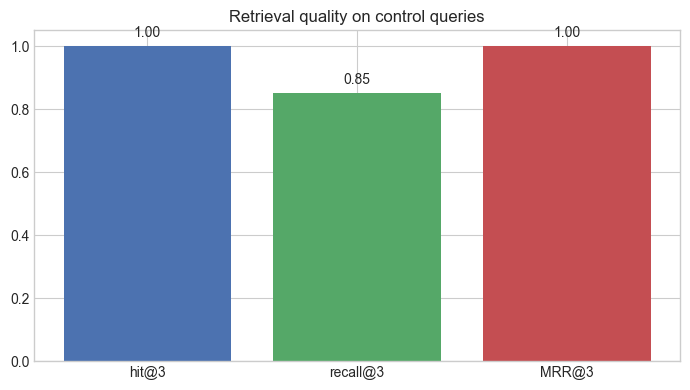

,metric,value
0,hit@3,1.00
1,recall@3,0.85
2,MRR@3,1.00


In [32]:
metrics_table = pd.DataFrame(
    [
        {"metric": "hit@3", "value": retrieval_metrics["hit_at_k"]},
        {"metric": "recall@3", "value": retrieval_metrics["recall_at_k"]},
        {"metric": "MRR@3", "value": retrieval_metrics["mrr_at_k"]},
    ]
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(metrics_table["metric"], metrics_table["value"], color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylim(0, 1.05)
ax.set_title("Retrieval quality on control queries")
for idx, value in enumerate(metrics_table["value"]):
    ax.text(idx, value + 0.03, f"{value:.2f}", ha="center", fontsize=10)
plt.tight_layout()
retrieval_plot_path = FIGURES_DIR / "retrieval_quality_plot.png"
plt.savefig(retrieval_plot_path, dpi=160, bbox_inches="tight")
plt.show()

metrics_table

## 5. Небольшой эксперимент по параметрам retrieval

Сравним два значения `chunk_size` при фиксированном overlap и посмотрим, как меняется retrieval quality.

In [33]:
experiment_rows = []
for candidate_chunk_size in [220, 320]:
    candidate_chunks = build_chunks(kb_df, chunk_size=candidate_chunk_size, overlap=MAIN_OVERLAP)
    candidate_system = build_retrieval_system(candidate_chunks)
    candidate_eval = evaluate_retrieval(eval_queries, candidate_system, top_k=TOP_K)

    experiment_rows.append(
        {
            "chunk_size": candidate_chunk_size,
            "overlap": MAIN_OVERLAP,
            "num_chunks": len(candidate_chunks),
            "hit_at_k": candidate_eval["hit_at_k"].mean(),
            "recall_at_k": candidate_eval["recall_at_k"].mean(),
            "mrr_at_k": candidate_eval["mrr_component"].mean(),
        }
    )

experiment_df = pd.DataFrame(experiment_rows).sort_values("chunk_size").reset_index(drop=True)
experiment_df

,chunk_size,overlap,num_chunks,hit_at_k,recall_at_k,mrr_at_k
0,220,70,71,1.0,0.85,1.0
1,320,70,46,1.0,0.85,1.0


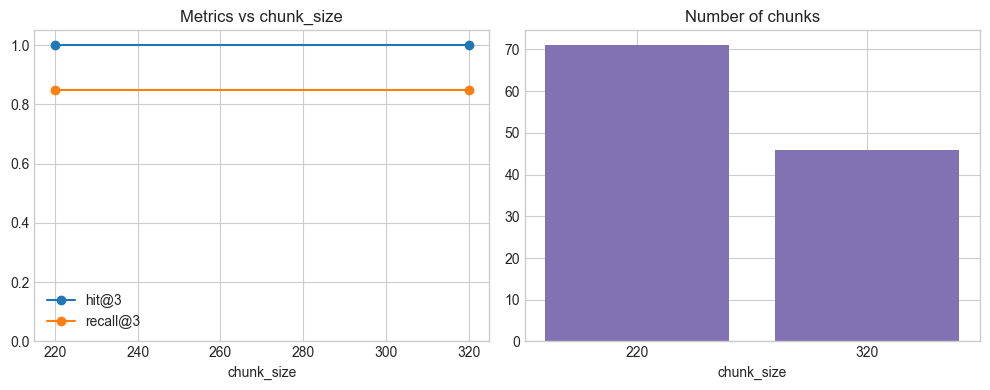

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(experiment_df["chunk_size"], experiment_df["hit_at_k"], marker="o", label="hit@3")
axes[0].plot(experiment_df["chunk_size"], experiment_df["recall_at_k"], marker="o", label="recall@3")
axes[0].set_title("Metrics vs chunk_size")
axes[0].set_xlabel("chunk_size")
axes[0].set_ylim(0, 1.05)
axes[0].legend()

axes[1].bar(experiment_df["chunk_size"].astype(str), experiment_df["num_chunks"], color="#8172B3")
axes[1].set_title("Number of chunks")
axes[1].set_xlabel("chunk_size")

plt.tight_layout()
experiment_plot_path = FIGURES_DIR / "chunk_size_experiment.png"
plt.savefig(experiment_plot_path, dpi=160, bbox_inches="tight")
plt.show()

## 6. Обновление базы знаний и переиндексация

Добавим несколько новых документов, заново выполним чанкинг и построение индекса, а затем сравним retrieval до и после обновления.

In [35]:
kb_update_docs = json.loads(KB_UPDATE_PATH.read_text(encoding="utf-8"))
kb_update_df = pd.DataFrame(kb_update_docs)
kb_updated_df = pd.concat([kb_df.drop(columns=["char_count", "word_count"]), kb_update_df], ignore_index=True)

updated_chunks_df = build_chunks(kb_updated_df, chunk_size=MAIN_CHUNK_SIZE, overlap=MAIN_OVERLAP)
updated_system = build_retrieval_system(updated_chunks_df)

print("Original document count:", len(kb_df))
print("Updated document count:", len(kb_updated_df))
print("Original chunk count:", len(chunks_df))
print("Updated chunk count:", len(updated_chunks_df))

Original document count: 12
Updated document count: 15
Original chunk count: 46
Updated chunk count: 55


In [36]:
update_queries = [
    "Why can overlap help when a fact sits near a chunk boundary?",
    "What does hybrid retrieval combine?",
    "What failure modes are common in mini RAG systems?",
    "How should we debug whether retrieval or answer generation caused an error?",
]

before_after_rows = []
for query in update_queries:
    before_df = retrieve(query, retrieval_system, top_k=TOP_K)
    after_df = retrieve(query, updated_system, top_k=TOP_K)

    before_sources = unique_in_order(before_df["source"].tolist())
    after_sources = unique_in_order(after_df["source"].tolist())

    before_after_rows.append(
        {
            "query": query,
            "before_retrieved_sources": " | ".join(before_sources),
            "after_retrieved_sources": " | ".join(after_sources),
            "changed": bool(before_sources != after_sources),
        }
    )

before_after_df = pd.DataFrame(before_after_rows)
before_after_path = ARTIFACTS_DIR / "retrieval_before_after_update.csv"
before_after_df.to_csv(before_after_path, index=False)
before_after_df

,query,before_retrieved_sources,after_retrieved_sources,changed
0,Why can overlap help when a fact sits near a chunk boundary?,doc_chunking_strategies | doc_time_series_split | doc_data_leakage,doc_chunking_strategies | doc_overlap_tuning,True
1,What does hybrid retrieval combine?,doc_embeddings_basics | doc_model_selection | doc_prompt_answering,doc_hybrid_search,True
2,What failure modes are common in mini RAG systems?,doc_embeddings_basics | doc_rag_pipeline,doc_rag_failure_modes,True
3,How should we debug whether retrieval or answer generation caused an error?,doc_rag_pipeline | doc_prompt_answering,doc_rag_pipeline | doc_prompt_answering,False


## 7. Mini-RAG

Для учебной версии mini-RAG не используем внешнюю LLM.
Ответ строится из предложений с максимальным пересечением по ключевым словам с вопросом, а рядом всегда возвращаются источники.

In [37]:
def tokenize_keywords(text: str):
    return [token for token in re.findall(r"[A-Za-z]{4,}", text.lower())]


def build_answer_from_context(question: str, retrieved_df: pd.DataFrame) -> str:
    keywords = set(tokenize_keywords(question))
    sentence_pool = []
    for _, row in retrieved_df.iterrows():
        sentences = re.split(r"(?<=[.!?])\s+", row["chunk_text"])
        for sentence in sentences:
            clean_sentence = sentence.strip()
            if not clean_sentence:
                continue
            sentence_tokens = set(tokenize_keywords(clean_sentence))
            overlap = len(keywords & sentence_tokens)
            score = overlap + (1.0 / row["rank"])
            sentence_pool.append((score, row["source"], clean_sentence))

    sentence_pool.sort(key=lambda item: item[0], reverse=True)

    selected = []
    seen_sentences = set()
    for score, source, sentence in sentence_pool:
        if sentence in seen_sentences:
            continue
        selected.append(sentence)
        seen_sentences.add(sentence)
        if len(selected) == 3:
            break

    if not selected:
        selected = retrieved_df["chunk_text"].head(2).tolist()

    return " ".join(selected)


def answer_question(question: str, system: dict, top_k: int = 3) -> dict:
    retrieved_df = retrieve(question, system, top_k=top_k)
    answer = build_answer_from_context(question, retrieved_df)
    sources = unique_in_order(retrieved_df["source"].tolist())
    return {
        "question": question,
        "answer": answer,
        "retrieved_sources": " | ".join(sources),
        "context_preview": " ".join(retrieved_df["chunk_text"].head(2).tolist())[:280] + "...",
    }

In [38]:
rag_questions = [
    "Why should a retrieval notebook keep a final test split untouched?",
    "How can TF-IDF vectors be searched with FAISS?",
    "Why is overlap useful for chunking?",
    "What does hybrid retrieval combine?",
    "What usually goes wrong in mini RAG systems?",
]

rag_rows = [answer_question(question, updated_system, top_k=TOP_K) for question in rag_questions]
rag_examples_df = pd.DataFrame(rag_rows)
rag_examples_path = ARTIFACTS_DIR / "rag_examples.csv"
rag_examples_df.to_csv(rag_examples_path, index=False)
rag_examples_df[["question", "answer", "retrieved_sources"]]

,question,answer,retrieved_sources
0,Why should a retrieval notebook keep a final test split untouched?,"For small datasets, cross validation can replace a fixed validation split, but the final test set should still remain isolated. The test...",doc_train_val_test
1,How can TF-IDF vectors be searched with FAISS?,"ter that, the vectors can be indexed in FAISS with inner product similarity. After that, the vectors can be indexed in FAISS with inner ...",doc_tfidf_vectorizer
2,Why is overlap useful for chunking?,"Overlap matters because a useful fact often sits near a chunk boundary; without overlap, the answer can be cut in half and retrieval qua...",doc_chunking_strategies | doc_overlap_tuning
3,What does hybrid retrieval combine?,Hybrid retrieval combines lexical matching and vector similarity. A lightweight educational notebook does not need to implement a full h...,doc_hybrid_search
4,What usually goes wrong in mini RAG systems?,"Mini RAG systems fail when retrieval brings weak context, when the context window contains too many partially relevant chunks or when th...",doc_rag_failure_modes | doc_rag_pipeline


## 8. Краткий анализ ошибок и ограничений

Ниже показаны несколько пограничных вопросов.
Они полезны не потому, что всегда проваливаются полностью, а потому что хорошо демонстрируют ограничения текущего pipeline.

In [39]:
borderline_cases = [
    {
        "question": "Why can retrieval quality look too optimistic when future information is present?",
        "likely_issue": "The query overlaps with both leakage and time-series documents, so retrieval can split evidence across sources.",
        "main_component": "retrieval + context assembly",
    },
    {
        "question": "How should we keep neighboring facts together without creating too many redundant chunks?",
        "likely_issue": "The question mixes chunk_size and overlap, so multiple chunking documents may compete for rank one.",
        "main_component": "chunking design",
    },
    {
        "question": "Why might a template answer sound repetitive even with relevant context?",
        "likely_issue": "Retrieval can be correct, but the answer builder only copies top-scoring sentences instead of rewriting them.",
        "main_component": "answer generation",
    },
]

borderline_df = pd.DataFrame(borderline_cases)
borderline_df

,question,likely_issue,main_component
0,Why can retrieval quality look too optimistic when future information is present?,"The query overlaps with both leakage and time-series documents, so retrieval can split evidence across sources.",retrieval + context assembly
1,How should we keep neighboring facts together without creating too many redundant chunks?,"The question mixes chunk_size and overlap, so multiple chunking documents may compete for rank one.",chunking design
2,Why might a template answer sound repetitive even with relevant context?,"Retrieval can be correct, but the answer builder only copies top-scoring sentences instead of rewriting them.",answer generation
